[Kaggle airline dataset](https://www.kaggle.com/datasets/rohitgrewal/airlines-flights-data)

In [1]:
%pip install seaborn numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Data/airlines_flights_data.csv', index_col='index')
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,,
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Data exploration and analysis

In [4]:
print('Data size:', df.size)
print('Data shape:', df.shape)

Data size: 3301683
Data shape: (300153, 11)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [6]:
df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [7]:
df.head(10)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,,
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954


In [8]:
df.describe().round(2)

,duration,days_left,price
count,300153.00,300153.00,300153.00
mean,12.22,26.00,20889.66
std,7.19,13.56,22697.77
min,0.83,1.00,1105.00
25%,6.83,15.00,4783.00
50%,11.25,26.00,7425.00
75%,16.17,38.00,42521.00
max,49.83,49.00,123071.00


No null values in dataset. Hence dataset is clean

In [9]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [10]:
# days left tells time from the booking date till trip date
df['days_left'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [11]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,,
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [12]:
# which airine has most flight frequency in data

frq_arl = df.groupby(['airline'])['flight'].count().reset_index()
frq_arl.columns = ['airline', 'flight_count']
frq_arl

,airline,flight_count
0,AirAsia,16098
1,Air_India,80892
2,GO_FIRST,23173
3,Indigo,43120
4,SpiceJet,9011
5,Vistara,127859


Which Airlines has highest no of flights

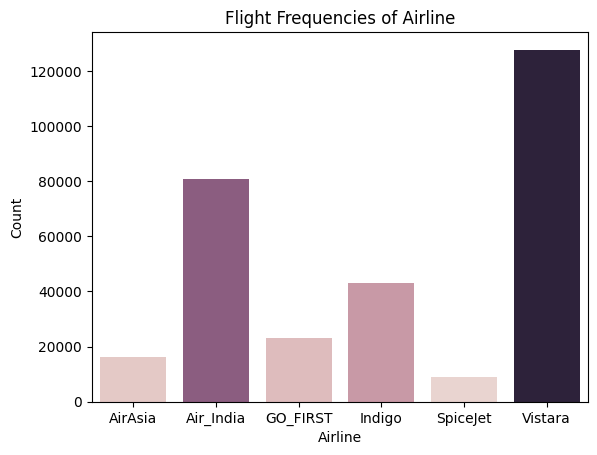

In [13]:
plt.figure()
sns.barplot(data=frq_arl,x='airline', y='flight_count', hue='flight_count', legend=False)
plt.title('Flight Frequencies of Airline')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.show()

Top 3 flights are Air India, Vistara and Indigo

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


Which Airline prefer what time slot for arrival and departure

For simplicity displaying only plot of top 3 airline

In [15]:

ar_flt = df.groupby(['airline'])['departure_time'].value_counts().reset_index()
ar_flt = ar_flt[ar_flt['airline'].isin(['Air_India', 'Vistara', 'Indigo'])]
ar_flt

,airline,departure_time,count
6,Air_India,Early_Morning,19867
7,Air_India,Evening,18626
8,Air_India,Morning,17768
9,Air_India,Night,13464
10,Air_India,Afternoon,10876
11,Air_India,Late_Night,291
18,Indigo,Morning,11491
19,Indigo,Afternoon,10155
20,Indigo,Evening,8460
21,Indigo,Early_Morning,8184


In [16]:
airIndia = ar_flt[ar_flt['airline'] == 'Air_India']
Vistara = ar_flt[ar_flt['airline'] == 'Vistara']
Indigo = ar_flt[ar_flt['airline'] == 'Indigo']


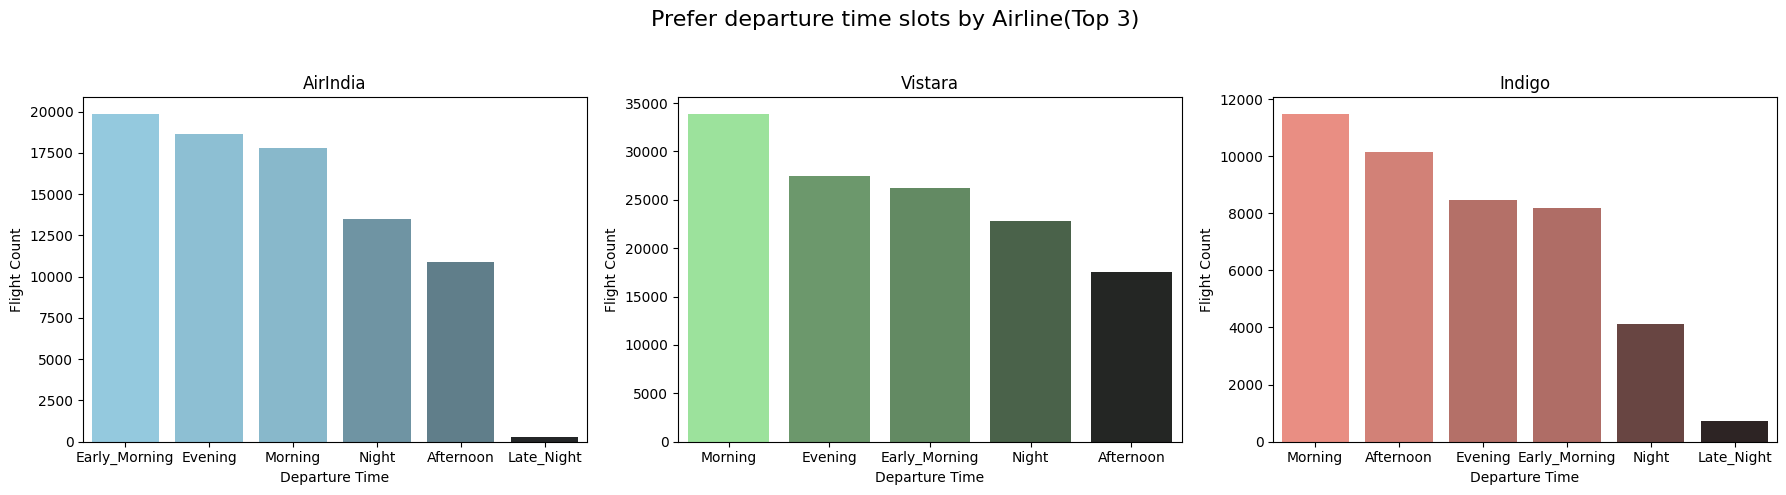

In [17]:
plt.figure(figsize=(18, 5))
plt.suptitle('Prefer departure time slots by Airline(Top 3)', fontsize=16)

plt.subplot(1, 3, 1)
sns.barplot(data=airIndia, x='departure_time', y='count', palette='dark:skyblue', hue='count', legend=False)
plt.title('AirIndia')
plt.xlabel('Departure Time')
plt.ylabel('Flight Count')


plt.subplot(1, 3, 2)
sns.barplot(data=Vistara, x='departure_time', y='count',  palette='dark:lightgreen', hue='count', legend=False)
plt.title('Vistara')
plt.xlabel('Departure Time')
plt.ylabel('Flight Count')



plt.subplot(1, 3, 3)
sns.barplot(data=Indigo, x='departure_time', y='count', palette='dark:salmon' ,hue='count', legend=False)
plt.title('Indigo')
plt.xlabel('Departure Time')
plt.ylabel('Flight Count')

plt.grid(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [18]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,,
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [23]:
cls_compr = df.groupby(['airline', 'class']).size().reset_index(name='count')
cls_compr

,airline,class,count
0,AirAsia,Economy,16098
1,Air_India,Business,32898
2,Air_India,Economy,47994
3,GO_FIRST,Economy,23173
4,Indigo,Economy,43120
5,SpiceJet,Economy,9011
6,Vistara,Business,60589
7,Vistara,Economy,67270


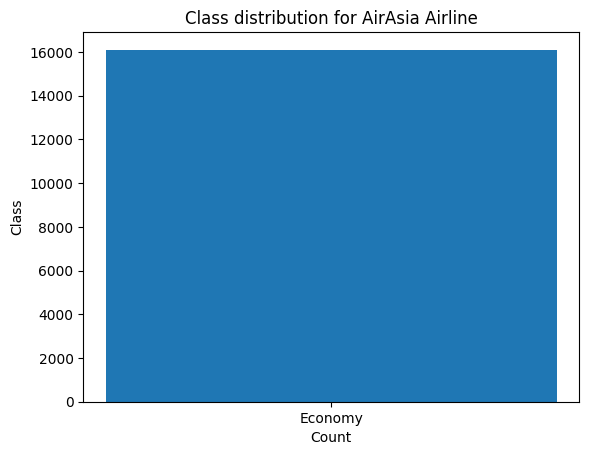

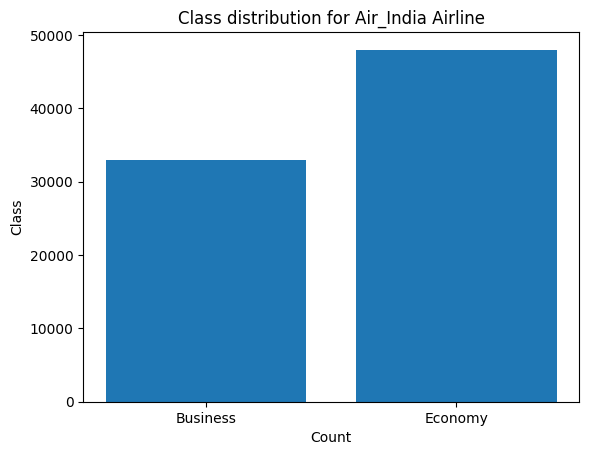

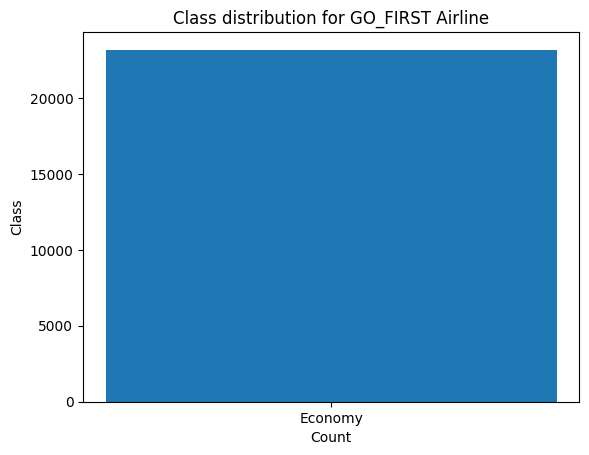

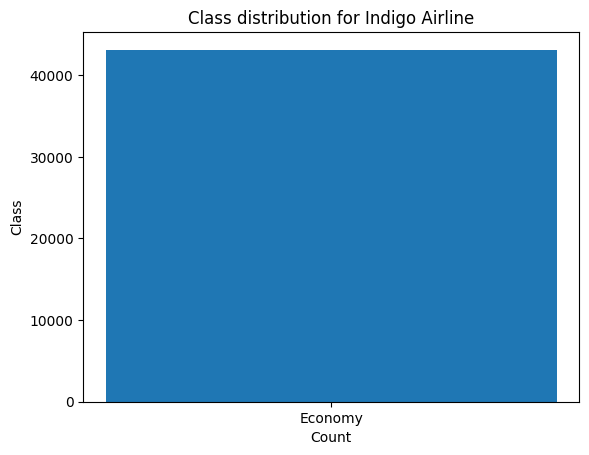

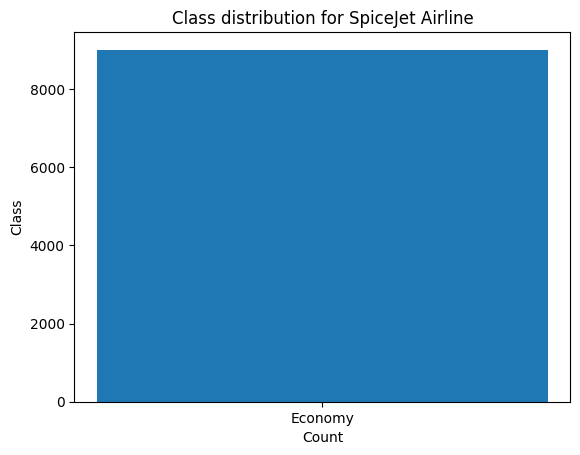

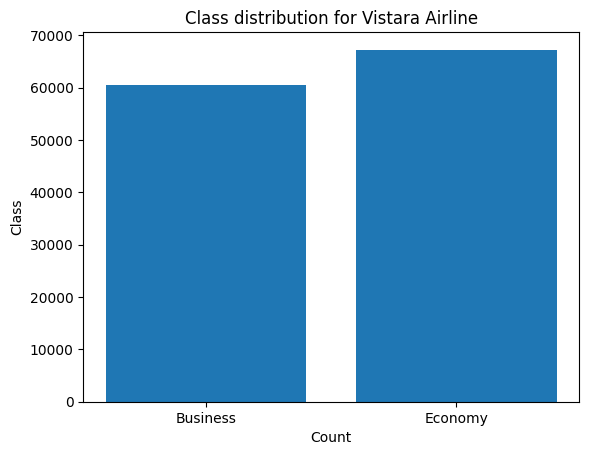

In [30]:
n = len(cls_compr['airline'].unique())

plt.figure()
for airline in cls_compr['airline'].unique():
    # filter data for airline
    subset = cls_compr[cls_compr['airline'] == airline]
    plt.bar(x=subset['class'], height=subset['count'])
    plt.title(f'Class distribution for {airline} Airline')
    plt.xlabel('Count')
    plt.ylabel('Class')
    plt.show()
    